# 06 · An experiment from scratch

Build a Gainesville maize experiment from weather, soil and YAML, then compare potential grain yield at two planting densities.

## You will learn

- Fill a FileX template without copying a stock FileX.
- Use experiment data YAML to give two treatments different planting densities.
- Check and run both treatments, then compare grain yield in a table and plot.

In [1]:
LESSON = "06_experiment_from_scratch"

In [2]:
# Connect to DSSAT and prepare a fresh copy of the lesson's data.
import os, shutil, subprocess, sys
from pathlib import Path
if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "dssatlab[course]>=0.23,<0.24"], check=True, capture_output=True)
    if Path.cwd().name != LESSON:
        if not Path("dssatlab").exists():
            subprocess.run(["git", "clone", "--depth", "1", "https://github.com/AbdelrahmanAmr3/dssatlab"], check=True)
        os.chdir(Path("dssatlab") / "course" / LESSON)
import dssatlab as dl
if "google.colab" in sys.modules:
    dl.install()
dssat = dl.connect()
HERE = Path.cwd()
RUNS = HERE / "runs"
if RUNS.exists():
    shutil.rmtree(RUNS)
_ = shutil.copytree(HERE / "data", RUNS)

Load the tools for YAML and inline plots.

In [3]:
# Load the lesson tools.
import yaml
import matplotlib.pyplot as plt
%matplotlib inline
print("Tools ready: YAML and plots.")

Tools ready: YAML and plots.


Inspect the copied weather and soil CSVs before building the experiment.

In [4]:
# Summarize the weather and soil inputs with their units.
weather_path = RUNS / "station_weather.csv"
soil_path = RUNS / "gainesville_soil.csv"
weather = dl.summarize_weather(weather_path)
soil = dl.summarize_soil(soil_path)
dl.to_dataframe([
    {"Input": weather_path.relative_to(HERE).as_posix(), "Description": "Weather dates", "Value": f"{weather['first_date']} to {weather['last_date']}"},
    {"Input": "UFGA", "Description": "Weather days", "Value": weather["days"]},
    {"Input": "UFGA", "Description": "Rain total (mm)", "Value": weather["rain_total"]},
    {"Input": soil_path.relative_to(HERE).as_posix(), "Description": "Soil profile", "Value": soil["soil_id"]},
    {"Input": soil["soil_id"], "Description": "Layers / depth (cm)", "Value": f"{soil['layers']} / {soil['depth']}"},
    {"Input": soil["soil_id"], "Description": "Extractable water (mm)", "Value": soil["extractable_water"]},
])

,Input,Description,Value
0,runs/station_weather.csv,Weather dates,1982-01-01 to 1982-12-31
1,UFGA,Weather days,365
2,UFGA,Rain total (mm),1544.5
3,runs/gainesville_soil.csv,Soil profile,IBMZ910014
4,IBMZ910014,Layers / depth (cm),8 / 180.0
5,IBMZ910014,Extractable water (mm),160.95


🌱 Crop idea  
These CSVs reproduce the stock Gainesville weather and Millhopper Fine Sand profile used in lessons 04/05.
This lesson supplies its own copies and creates its FileX from scratch.

Write a FileX template and preview its active YAML fields to see the required shape.

In [5]:
# Write the example template and display its active fields.
filex_path = RUNS / "experiment_filex.yaml"
dl.write_filex_template(filex_path)
example_template = yaml.safe_load(filex_path.read_text(encoding="utf-8"))
print("Template:", filex_path.relative_to(HERE).as_posix())
print(yaml.safe_dump(example_template, sort_keys=False).rstrip())

Template: runs/experiment_filex.yaml
crop: maize
treatment_name: My treatment
cultivar:
  code: IB0035
planting:
  date: '2021-03-01'
  method: S
  distribution: R
  population: 7.2
  row_spacing: 75
  depth: 5


Replace the example with the prepared Gainesville recipe, giving two named treatments the same cultivar and base planting.

In [6]:
# Fill the generated template with the lesson's Gainesville recipe.
recipe_path = RUNS / "filex.yaml"
template = yaml.safe_load(recipe_path.read_text(encoding="utf-8"))
filex_path.write_text(yaml.safe_dump(template, sort_keys=False), encoding="utf-8")
print("Recipe:", recipe_path.relative_to(HERE).as_posix())
print(filex_path.read_text(encoding="utf-8").rstrip())

Recipe: runs/filex.yaml
crop: maize
treatments:
- Sparse 4 plants/m2
- Dense 8 plants/m2
cultivar:
  code: IB0035
planting:
  date: '1982-02-26'
  method: S
  distribution: R
  population: 4
  row_spacing: 61
  depth: 7


🐍 Python idea  
YAML stores named values; `safe_load()` reads them into a dictionary and `safe_dump()` writes them back.
The treatment list assigns numbers 1 and 2; `IB0035` is McCurdy 84aa, and omitting `harvest_date` harvests at maturity.

Read the experiment data YAML that keeps water and nitrogen off and changes treatment 2 to 8 plants/m².

In [7]:
# Show the experiment data for both treatment numbers.
experiment_path = RUNS / "experiment.yaml"
print("Experiment data:", experiment_path.relative_to(HERE).as_posix())
print(experiment_path.read_text(encoding="utf-8").rstrip())

Experiment data: runs/experiment.yaml
treatments:
  1:
    controls:
      water: "N"
      nitrogen: "N"
  2:
    planting:
      date: "1982-02-26"
      method: "S"
      distribution: "R"
      population: 8
      emergence_population: 8
      row_spacing: 61
      depth: 7
    controls:
      water: "N"
      nitrogen: "N"


🌱 Crop idea  
Treatment 1 keeps 4 plants/m² from the FileX template; treatment 2 replaces the whole planting section with 8 plants/m² at sowing and emergence.
Both use seed in rows (`S`/`R`), 61 cm row spacing and 7 cm planting depth; water and nitrogen simulation off means this compares potential production.

Build a Simulation for each treatment and check the YAML, site data and dates before running DSSAT.

In [8]:
# Check both treatments before generating DSSAT files.
inputs = {
    "filex_template": filex_path,
    "weather": weather_path,
    "soil": soil_path,
    "management": experiment_path,
    "executable": dssat,
}
simulations = {number: dl.Simulation(**inputs, treatment=number) for number in (1, 2)}
for number, sim in simulations.items():
    problems = sim.check(verbose=False)
    print(f"Treatment {number} problems:", problems)

Treatment 1 problems: []
Treatment 2 problems: []


Run both treatments; dssatlab writes the FileX, weather and soil files and uses installed maize genotype files.

In [9]:
# Run both checked treatments and locate their results.
results = {number: sim.run() for number, sim in simulations.items()}
for number, result in results.items():
    print(f"Treatment {number}: exit {result.returncode}; {result.run_dir.relative_to(HERE).as_posix()}")

Treatment 1: exit 0; runs/dssat_sim_2026-10-06_202937/dssat_run_2026-10-06_202937
Treatment 2: exit 0; runs/dssat_sim_2026-10-06_202938/dssat_run_2026-10-06_202938


Compare grain yield (`HWAM`, kg/ha), aboveground biomass at maturity (`CWAM`, kg/ha), anthesis (`ADAT`) and maturity (`MDAT`).

In [10]:
# Read one Summary row per treatment into a comparison table.
summary_rows = []
for result in results.values():
    summary_rows.extend(dl.read_summary(result.run_dir))
comparison = dl.to_dataframe(summary_rows)
comparison[["TRNO", "TNAM", "HWAM", "CWAM", "ADAT", "MDAT"]]

,TRNO,TNAM,HWAM,CWAM,ADAT,MDAT
0,1,Sparse 4 plants/m2,10080,17638,1982-05-13,1982-07-04
1,2,Dense 8 plants/m2,12093,24136,1982-05-13,1982-07-04


Plot potential grain yield to see the response to planting density in this one season.

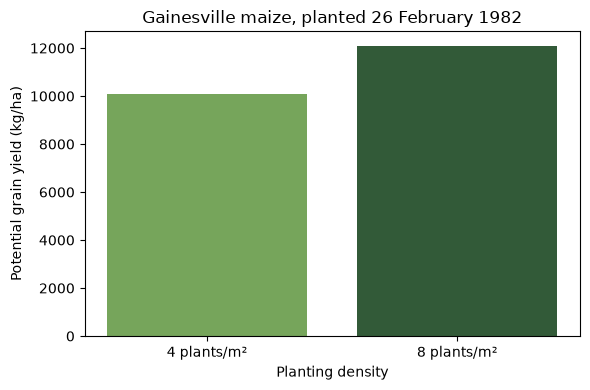

In [11]:
# Plot the two treatment yields with agronomic units.
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["4 plants/m²", "8 plants/m²"], comparison["HWAM"], color=["#76a55b", "#325a38"])
ax.set_xlabel("Planting density")
ax.set_ylabel("Potential grain yield (kg/ha)")
ax.set_title("Gainesville maize, planted 26 February 1982")
fig.tight_layout()
plt.show()

🌱 Crop idea  
At 8 plants/m², yield is 12,093 kg/ha versus 10,080 at 4 plants/m²: a gain of 2,013 kg/ha (20.0%).
This is one cultivar and one weather year with water and nitrogen simulation off; it does not establish a density recommendation when those resources limit growth.

## Your turn

Compare the sparse treatment with a density of your choice using the same site and potential-production controls.

Hint: edit `chosen_density = 6` (plants/m²), then run this cell.

In [12]:
# Rebuild the experiment and compare a chosen density with 4 plants per square metre.
chosen_density = 6
exercise_template = yaml.safe_load((RUNS / "filex.yaml").read_text(encoding="utf-8"))
exercise_data = yaml.safe_load((RUNS / "experiment.yaml").read_text(encoding="utf-8"))
exercise_template["treatments"][1] = f"Choice {chosen_density} plants/m2"
exercise_data["treatments"][2]["planting"]["population"] = chosen_density
exercise_data["treatments"][2]["planting"]["emergence_population"] = chosen_density
exercise_path = RUNS / "density_exercise.yaml"
exercise_path.write_text(yaml.safe_dump(exercise_template, sort_keys=False), encoding="utf-8")
exercise_rows = []
for number in (1, 2):
    exercise_sim = dl.Simulation(
        filex_template=exercise_path, treatment=number,
        weather=RUNS / "station_weather.csv",
        soil=RUNS / "gainesville_soil.csv",
        management=exercise_data, executable=dssat,
    )
    exercise_result = exercise_sim.run()
    exercise_rows.extend(dl.read_summary(exercise_result.run_dir))
exercise_table = dl.to_dataframe(exercise_rows)
exercise_table["Gain over sparse (kg/ha)"] = exercise_table["HWAM"] - exercise_table.loc[0, "HWAM"]
exercise_table[["TRNO", "TNAM", "HWAM", "Gain over sparse (kg/ha)"]]

,TRNO,TNAM,HWAM,Gain over sparse (kg/ha)
0,1,Sparse 4 plants/m2,10080,0
1,2,Choice 6 plants/m2,11371,1291


## Recap

- A FileX template defines the crop, cultivar, planting and named treatments; weather and soil CSVs supply the field.
- Experiment data keyed by treatment number changes management and controls; a planting override supplies the whole section.
- Checks precede the runs, and Summary tables and inline plots compare simulated potential yields.

Next: [07 · Simulated vs observed](../07_simulated_vs_observed/lesson.ipynb).